In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from PIL import Image
from tensorflow.keras import layers, Model
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split

# Ciphar-10 dataset(0 : airplane, 1 : automobile, and 2 : truck)

In [2]:

# Step 1: Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Filter for classes 0 (airplane), 1 (automobile), and 9 (truck)
train_mask = np.isin(y_train, [0, 1, 9])
test_mask = np.isin(y_test, [0, 1, 9])

x_train = x_train[train_mask.reshape(-1)]
y_train = y_train[train_mask.reshape(-1)]
x_test = x_test[test_mask.reshape(-1)]
y_test = y_test[test_mask.reshape(-1)]

# Remap labels to 0, 1, 2
label_map = {0: 0, 1: 1, 9: 2}
y_train = np.array([label_map[y[0]] for y in y_train])
y_test = np.array([label_map[y[0]] for y in y_test])

# Step 2: Minimize the dataset size by selecting a random subset
subset_size = 0.05  # 10% of the dataset
train_sample_size = int(len(x_train) * subset_size)
test_sample_size = int(len(x_test) * subset_size)

train_indices = np.random.choice(len(x_train), train_sample_size, replace=False)
test_indices = np.random.choice(len(x_test), test_sample_size, replace=False)

x_train = x_train[train_indices]
y_train = y_train[train_indices]
x_test = x_test[test_indices]
y_test = y_test[test_indices]

# Step 3: Define function to save images into folders
def save_images_to_folders(data, labels, base_dir):
    os.makedirs(base_dir, exist_ok=True)
    for label in np.unique(labels):
        label_dir = os.path.join(base_dir, str(label))
        os.makedirs(label_dir, exist_ok=True)

    for i, (image, label) in enumerate(zip(data, labels)):
        label_dir = os.path.join(base_dir, str(label))
        img = Image.fromarray(image)
        img.save(os.path.join(label_dir, f"{i}.png"))

# Step 4: Save training and test data into respective folders
save_images_to_folders(x_train, y_train, "cifar10/train")
save_images_to_folders(x_test, y_test, "cifar10/test")

print("Dataset saved in 'cifar10/train' and 'cifar10/test' folders.")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Dataset saved in 'cifar10/train' and 'cifar10/test' folders.


In [3]:
# Step: Split training set into training and validation sets
validation_subset_size = 0.2  # 20% of the training dataset
validation_sample_size = int(len(x_train) * validation_subset_size)

validation_indices = np.random.choice(len(x_train), validation_sample_size, replace=False)
train_indices = np.setdiff1d(np.arange(len(x_train)), validation_indices)

x_validation = x_train[validation_indices]
y_validation = y_train[validation_indices]

# Step: Save validation data into the 'cifar10/validation' folder
save_images_to_folders(x_validation, y_validation, "cifar10/validation")

print("Validation dataset saved in 'cifar10/validation' folder.")

Validation dataset saved in 'cifar10/validation' folder.


# creating masks using k-means clustering

In [4]:
from pathlib import Path

def create_colored_mask(image_path):
    """
    Create a colorful mask suitable for U-Net training using K-means clustering
    with distinct colors for each segment.
    """
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Could not read image at {image_path}")

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    pixels = image_rgb.reshape(-1, 3)
    pixels = np.float32(pixels)

    K = 3  # Number of clusters (you can adjust this based on your dataset)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(pixels, K, None, criteria, 10,
                                     cv2.KMEANS_RANDOM_CENTERS)

    centers = np.uint8(centers)
    segmented_image = centers[labels.flatten()]
    segmented_image = segmented_image.reshape(image_rgb.shape)

    # Convert to colorful mask by simply keeping the segmented color information
    # Each segment will have its own color based on K-means centroids
    colored_mask = segmented_image

    # Optionally, you can enhance the mask with morphological operations
    kernel = np.ones((3, 3), np.uint8)
    colored_mask = cv2.morphologyEx(colored_mask, cv2.MORPH_OPEN, kernel)
    colored_mask = cv2.morphologyEx(colored_mask, cv2.MORPH_CLOSE, kernel)

    return colored_mask

def process_dataset(input_dir, output_dir):
    """
    Process dataset maintaining the original train/validation/test and class structure
    """
    # Create base output directory
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    # Process all three splits
    for split in ['train', 'validation', 'test']:
        split_path = os.path.join(input_dir, split)
        if not os.path.exists(split_path):
            print(f"Split directory {split_path} not found, skipping...")
            continue

        # Create corresponding output split directory
        output_split_path = os.path.join(output_dir, split)
        Path(output_split_path).mkdir(parents=True, exist_ok=True)

        print(f"\nProcessing {split} split...")

        # Process each class directory
        for class_dir in sorted(os.listdir(split_path)):
            class_path = os.path.join(split_path, class_dir)
            if not os.path.isdir(class_path):
                continue

            # Create output class directory
            output_class_path = os.path.join(output_split_path, class_dir)
            Path(output_class_path).mkdir(parents=True, exist_ok=True)

            print(f"Processing class {class_dir}...")
            processed_count = 0
            error_count = 0

            # Process all images in the class directory
            for img_name in sorted(os.listdir(class_path)):
                if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    continue

                img_path = os.path.join(class_path, img_name)
                try:
                    # Generate colorful mask
                    mask = create_colored_mask(img_path)

                    # Save colorful mask with same name as original image
                    mask_path = os.path.join(output_class_path, img_name)
                    cv2.imwrite(mask_path, mask)
                    processed_count += 1

                    # Print progress every 100 images
                    if processed_count % 100 == 0:
                        print(f"Processed {processed_count} images in class {class_dir}")

                except Exception as e:
                    error_count += 1
                    print(f"Error processing {img_path}: {str(e)}")

            print(f"Completed class {class_dir}:")
            print(f"Successfully processed: {processed_count} images")
            print(f"Errors encountered: {error_count} images")

def main():
    input_dir = "cifar10"  # Your CIFAR10 directory
    output_dir = "masks_kmeans"   # Output directory for colorful masks

    process_dataset(input_dir, output_dir)

    # Print final statistics
    print("\nFinal Statistics:")
    for split in ['train', 'validation', 'test']:
        split_path = os.path.join(output_dir, split)
        if os.path.exists(split_path):
            total_masks = sum(len(files) for _, _, files in os.walk(split_path))
            print(f"Total masks created for {split}: {total_masks}")

if __name__ == "__main__":
    main()



Processing train split...
Processing class 0...
Processed 100 images in class 0
Processed 200 images in class 0
Completed class 0:
Successfully processed: 238 images
Errors encountered: 0 images
Processing class 1...
Processed 100 images in class 1
Processed 200 images in class 1
Completed class 1:
Successfully processed: 264 images
Errors encountered: 0 images
Processing class 2...
Processed 100 images in class 2
Processed 200 images in class 2
Completed class 2:
Successfully processed: 248 images
Errors encountered: 0 images

Processing validation split...
Processing class 0...
Completed class 0:
Successfully processed: 50 images
Errors encountered: 0 images
Processing class 1...
Completed class 1:
Successfully processed: 49 images
Errors encountered: 0 images
Processing class 2...
Completed class 2:
Successfully processed: 51 images
Errors encountered: 0 images

Processing test split...
Processing class 0...
Completed class 0:
Successfully processed: 62 images
Errors encountered: 0

# <span style="color:blue">**U-NET**</span>

In [5]:
### Pre-processing
IMG_CHANNELS = 3
IMG_WIDTH = 128
IMG_HEIGHT = 128
image_size = (IMG_WIDTH, IMG_HEIGHT)
BATCH_SIZE = 32
BUFFER_SIZE = tf.data.AUTOTUNE

def create_dataset(image_dir, mask_dir, image_size, batch_size, buffer_size):
    # Create image dataset
    image_dataset = tf.keras.utils.image_dataset_from_directory(
        image_dir,
        labels=None,
        label_mode=None,
        color_mode='rgb',
        image_size=image_size,
        batch_size=None,  # Remove batching here
        shuffle=True,
        seed=42
    )

    # Create mask dataset
    mask_dataset = tf.keras.utils.image_dataset_from_directory(
        mask_dir,
        labels=None,
        label_mode=None,
        color_mode='grayscale',  # Change to grayscale for masks
        image_size=image_size,
        batch_size=None,  # Remove batching here
        shuffle=True,
        seed=42
    )

    # Zip datasets together
    dataset = tf.data.Dataset.zip((image_dataset, mask_dataset))

    # Preprocessing function
    def preprocess(image, mask):
        # Normalize images to [0,1]
        image = tf.cast(image, tf.float32) / 255.0

        # Convert mask to binary and one-hot encode
        mask = tf.cast(mask >= 128, tf.float32)
        mask = tf.one_hot(tf.cast(mask[:,:,0], tf.int32), 2)
        return image, mask

    # Apply preprocessing, batching, and prefetching
    dataset = dataset.map(preprocess, num_parallel_calls=buffer_size)
    dataset = dataset.shuffle(1000)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=buffer_size)

    return dataset

# Create datasets
train_dataset = create_dataset(
    "cifar10/train",
    "masks_kmeans/train",
    image_size,
    BATCH_SIZE,
    BUFFER_SIZE
)

val_dataset = create_dataset(
    "cifar10/validation",
    "masks_kmeans/validation",
    image_size,
    BATCH_SIZE,
    BUFFER_SIZE
)

### Model
def unet_model(input_shape):
    inputs = tf.keras.layers.Input(input_shape)

    # Add BatchNormalization after inputs
    x = layers.BatchNormalization()(inputs)

    # Encoder
    conv1 = layers.Conv2D(64, 3, padding='same')(x)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.Activation('relu')(conv1)
    conv1 = layers.Conv2D(64, 3, padding='same')(conv1)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.Activation('relu')(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)
    pool1 = layers.Dropout(0.25)(pool1)  # Add dropout

    conv2 = layers.Conv2D(128, 3, padding='same')(pool1)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = layers.Activation('relu')(conv2)
    conv2 = layers.Conv2D(128, 3, padding='same')(conv2)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = layers.Activation('relu')(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)
    pool2 = layers.Dropout(0.3)(pool2)  # Add dropout

    # Bottleneck
    conv3 = layers.Conv2D(256, 3, padding='same')(pool2)
    conv3 = layers.BatchNormalization()(conv3)
    conv3 = layers.Activation('relu')(conv3)
    conv3 = layers.Conv2D(256, 3, padding='same')(conv3)
    conv3 = layers.BatchNormalization()(conv3)
    conv3 = layers.Activation('relu')(conv3)
    conv3 = layers.Dropout(0.4)(conv3)  # Add dropout

    # Decoder
    up1 = layers.UpSampling2D(size=(2, 2))(conv3)
    up1 = layers.Conv2D(128, 2, padding='same')(up1)
    up1 = layers.BatchNormalization()(up1)
    up1 = layers.Activation('relu')(up1)
    merge1 = layers.concatenate([conv2, up1], axis=3)
    merge1 = layers.Dropout(0.3)(merge1)  # Add dropout

    conv4 = layers.Conv2D(128, 3, padding='same')(merge1)
    conv4 = layers.BatchNormalization()(conv4)
    conv4 = layers.Activation('relu')(conv4)
    conv4 = layers.Conv2D(128, 3, padding='same')(conv4)
    conv4 = layers.BatchNormalization()(conv4)
    conv4 = layers.Activation('relu')(conv4)

    up2 = layers.UpSampling2D(size=(2, 2))(conv4)
    up2 = layers.Conv2D(64, 2, padding='same')(up2)
    up2 = layers.BatchNormalization()(up2)
    up2 = layers.Activation('relu')(up2)
    merge2 = layers.concatenate([conv1, up2], axis=3)
    merge2 = layers.Dropout(0.25)(merge2)  # Add dropout

    conv5 = layers.Conv2D(64, 3, padding='same')(merge2)
    conv5 = layers.BatchNormalization()(conv5)
    conv5 = layers.Activation('relu')(conv5)
    conv5 = layers.Conv2D(64, 3, padding='same')(conv5)
    conv5 = layers.BatchNormalization()(conv5)
    conv5 = layers.Activation('relu')(conv5)

    # Changed output to 2 channels (binary segmentation) with sigmoid activation
    outputs = layers.Conv2D(2, 1, activation='sigmoid')(conv5)

    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    return model

# Create and compile model
model = unet_model((IMG_WIDTH, IMG_HEIGHT, IMG_CHANNELS))
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),  # Changed loss function
    metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=2)]  # Added IoU metric
)

# Add more callbacks for better training
callbacks = [
    tf.keras.callbacks.TerminateOnNaN(),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=3),
    tf.keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True)
]



Found 750 files.
Found 750 files.
Found 150 files.
Found 150 files.


In [6]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.7781 - loss: 0.5022 - mean_io_u: 0.2500 - val_accuracy: 0.4789 - val_loss: 0.6922 - val_mean_io_u: 0.2500 - learning_rate: 1.0000e-04
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 343ms/step - accuracy: 0.9053 - loss: 0.2508 - mean_io_u: 0.2500 - val_accuracy: 0.5170 - val_loss: 0.7045 - val_mean_io_u: 0.2500 - learning_rate: 1.0000e-04
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 353ms/step - accuracy: 0.9144 - loss: 0.2172 - mean_io_u: 0.2500 - val_accuracy: 0.6102 - val_loss: 0.6173 - val_mean_io_u: 0.2500 - learning_rate: 1.0000e-04
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 358ms/step - accuracy: 0.9128 - loss: 0.2137 - mean_io_u: 0.2500 - val_accuracy: 0.6839 - val_loss: 0.5111 - val_mean_io_u: 0.2500 - learning_rate: 1.0000e-04
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 360ms/step - accuracy: 0.9115 - loss: 0.2118 - mean_io_u: 0.2500 - val_accuracy: 0.7116 - val_loss: 0.4827 - val_mean_io_u: 0.2500 - learning_rate: 1.0000e-04
E

In [7]:
# Save the model
model.save('seg_model.h5',save_format='tf')

# predictng masks from segmentation model

In [17]:
def load_and_preprocess_image(image_path, image_size=(128, 128)):
    """Load and preprocess a single image for prediction"""
    # Read image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize
    img = cv2.resize(img, image_size)

    # Normalize
    img = img.astype('float32') / 255.0

    return img

def generate_and_save_masks(model, input_dir, output_dir):
    """Generate masks using trained U-Net model and save them"""
    os.makedirs(output_dir, exist_ok=True)

    # Process each split (train/validation/test)
    for split in ['train', 'validation', 'test']:
        split_input = os.path.join(input_dir, split)
        split_output = os.path.join(output_dir, split)

        if not os.path.exists(split_input):
            continue

        os.makedirs(split_output, exist_ok=True)

        # Process each class directory
        for class_dir in os.listdir(split_input):
            class_input = os.path.join(split_input, class_dir)
            class_output = os.path.join(split_output, class_dir)

            if not os.path.isdir(class_input):
                continue

            os.makedirs(class_output, exist_ok=True)
            print(f"Processing {split}/{class_dir}")

            # Process each image
            for img_name in os.listdir(class_input):
                if not img_name.endswith(('.png', '.jpg', '.jpeg')):
                    continue

                # Load and preprocess image
                img_path = os.path.join(class_input, img_name)
                img = load_and_preprocess_image(img_path)

                # Generate mask using U-Net
                mask_pred = model.predict(np.expand_dims(img, 0), verbose=0)[0]

                # Convert prediction to image format
                mask_img = (np.argmax(mask_pred, axis=-1) * 255).astype(np.uint8)

                # Save mask
                output_path = os.path.join(class_output, img_name)
                cv2.imwrite(output_path, mask_img)

# Now run the mask generation
segmentation_model = unet_model((IMG_WIDTH, IMG_HEIGHT, IMG_CHANNELS))
segmentation_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=2)]
)

# Load weights
segmentation_model.load_weights('seg_model.h5')

# Generate masks
generate_and_save_masks(
    model=segmentation_model,
    input_dir='cifar10',
    output_dir='predicted_masks'
)

Processing train/1
Processing train/2
Processing train/0
Processing validation/1
Processing validation/2
Processing validation/0
Processing test/1
Processing test/2
Processing test/0


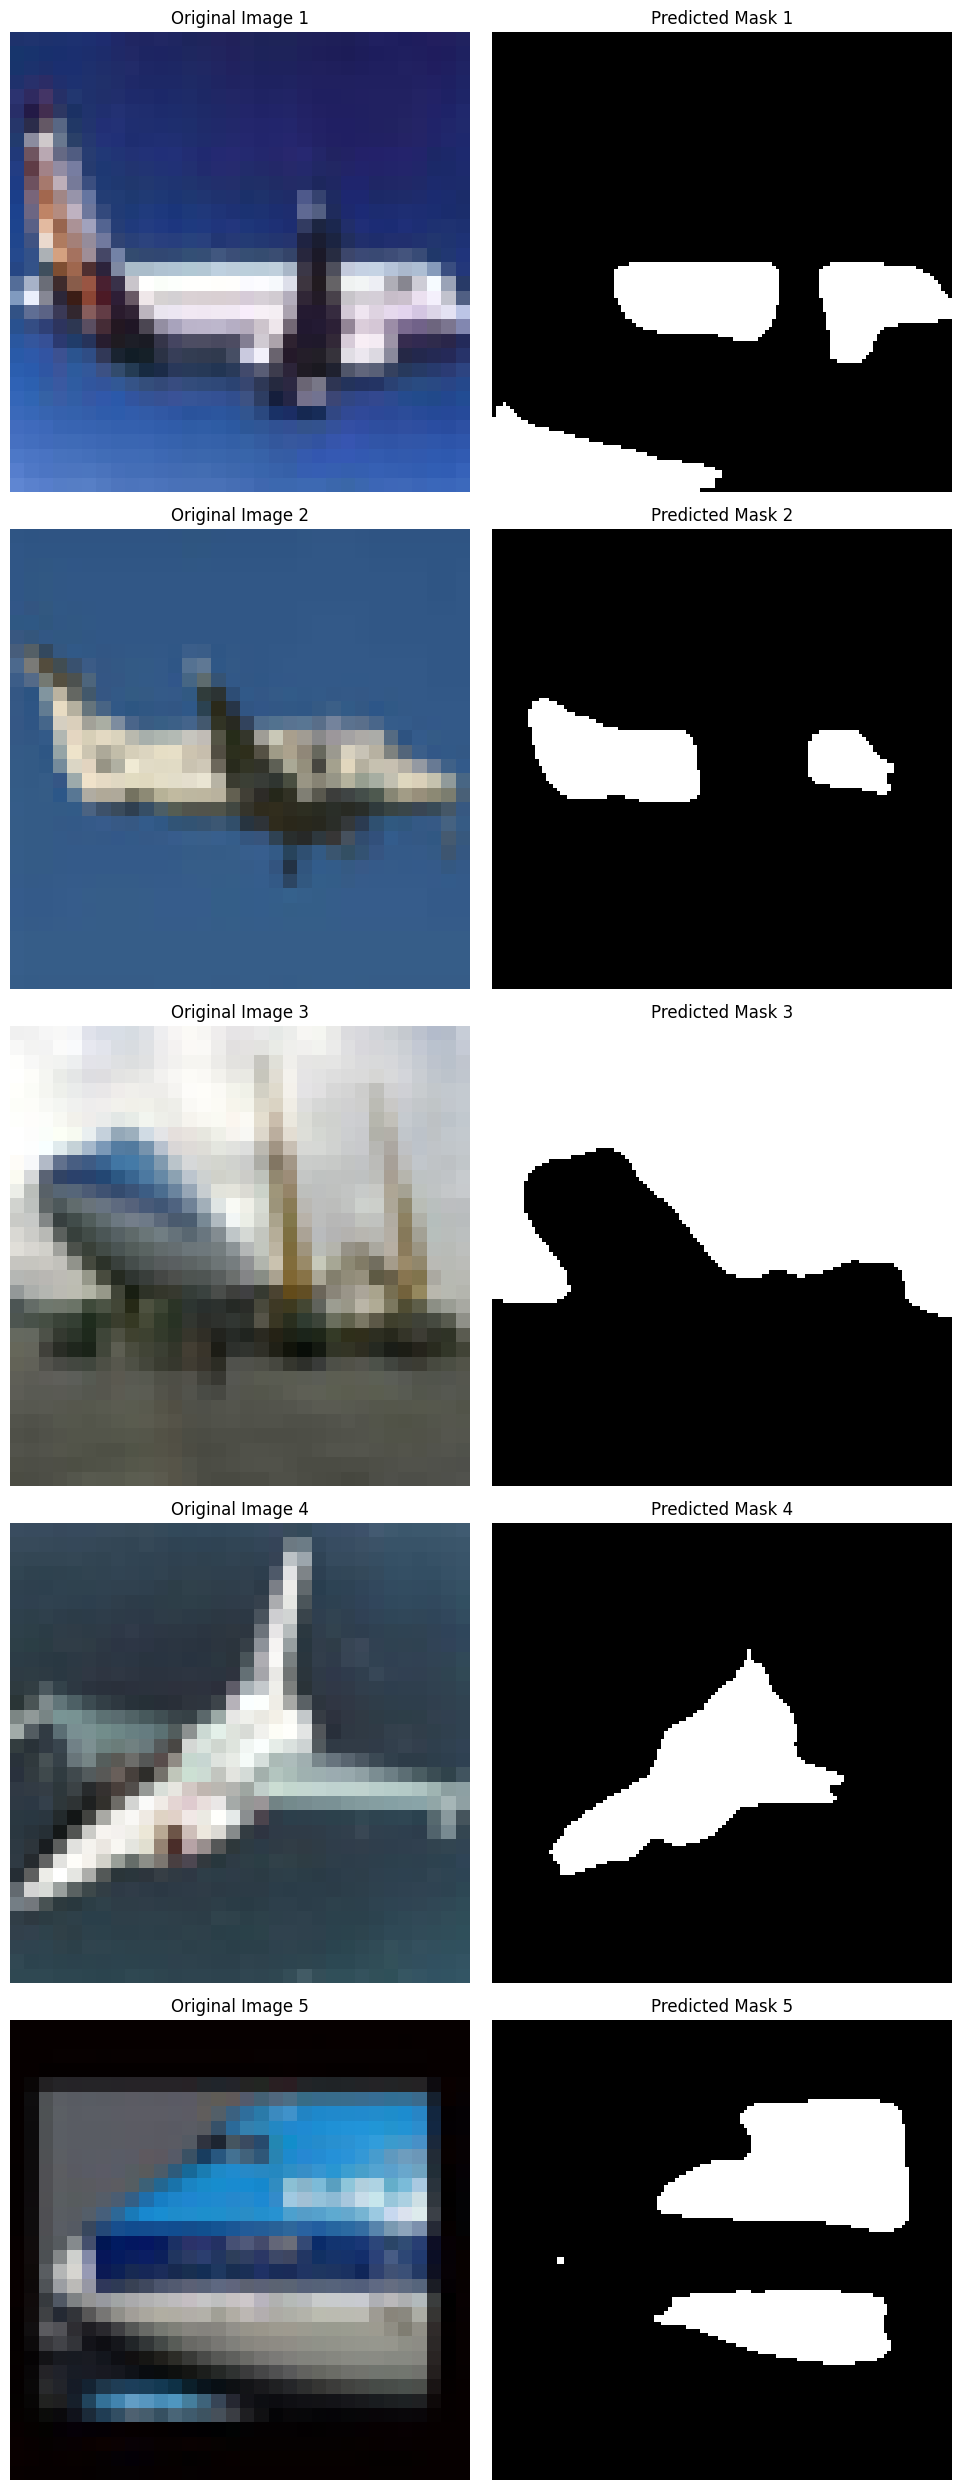

In [18]:

def visualize_predictions(image_dir, mask_dir, num_images=5):
    image_files = [f for f in os.listdir(image_dir) if os.path.isfile(os.path.join(image_dir, f))]

    num_images = min(num_images, len(image_files))

    fig, axes = plt.subplots(num_images, 2, figsize=(10, 5 * num_images))

    for i in range(num_images):
        image_path = os.path.join(image_dir, image_files[i])
        mask_path = os.path.join(mask_dir, image_files[i])

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        axes[i, 0].imshow(image)
        axes[i, 0].set_title(f'Original Image {i+1}')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title(f'Predicted Mask {i+1}')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

image_directory = 'cifar10/test/0'
mask_directory = 'predicted_masks/test/0'

visualize_predictions(image_directory, mask_directory, num_images = 5)

In [19]:
def create_segmentation_based_dataset(image_dir, mask_dir):
    """Create a dataset combining original images with their segmentation masks"""

    def load_and_process_data(image_path, mask_path, label):
        # Load image
        image = tf.io.read_file(image_path)
        image = tf.image.decode_png(image, channels=3)
        image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
        image = tf.cast(image, tf.float32) / 255.0

        # Load mask
        mask = tf.io.read_file(mask_path)
        mask = tf.image.decode_png(mask, channels=1)  # This loads the image as grayscale with 1 channel
        mask = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE])

        # replicate grayscale channel 3 times to get 3 channels
        mask = tf.image.grayscale_to_rgb(mask)  # Convert to 3 channel RGB by replicating the existing grayscale info
        mask = tf.cast(mask, tf.float32) / 255.0

        # Combine image and mask
        combined = tf.concat([image, mask], axis=-1)  # Now 4 channels (3 RGB + 1 mask)

        return combined, label

    # Lists to store paths and labels
    image_paths = []
    mask_paths = []
    labels = []

    # Collect data from training directory
    base_dir = os.path.join(image_dir, "train")
    mask_base_dir = os.path.join(mask_dir, "train")

    for class_idx, class_name in enumerate(sorted(os.listdir(base_dir))):
        class_dir = os.path.join(base_dir, class_name)
        mask_dir = os.path.join(mask_base_dir, class_name)

        if not os.path.isdir(class_dir):
            continue

        for img_name in os.listdir(class_dir):
            if img_name.endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(class_dir, img_name))
                mask_paths.append(os.path.join(mask_dir, img_name))
                labels.append(class_idx)

    # Convert to numpy arrays
    image_paths = np.array(image_paths)
    mask_paths = np.array(mask_paths)
    labels = np.array(labels)

    # Split into train and validation
    train_images, val_images, train_masks, val_masks, train_labels, val_labels = train_test_split(
        image_paths, mask_paths, labels, test_size=0.2, random_state=42
    )

    # Create training dataset
    train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_masks, train_labels))
    train_dataset = train_dataset.map(load_and_process_data, num_parallel_calls=tf.data.AUTOTUNE)
    train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # Create validation dataset
    val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_masks, val_labels))
    val_dataset = val_dataset.map(load_and_process_data, num_parallel_calls=tf.data.AUTOTUNE)
    val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return train_dataset, val_dataset

In [20]:
# Constants
IMG_SIZE = 128
BATCH_SIZE = 32
NUM_CLASSES = 3  # airplane, automobile, truck

# **Classifier**

In [21]:
def create_classification_model():
    """Creating a MobileNetV2-based model for classification with segmentation information"""

    # Input layer for combined image and mask (6 channels)
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 6))

    # Split input into image and mask
    image_input = inputs[:, :, :, :3]
    mask_input = inputs[:, :, :, 3:]

    # Create base model (MobileNetV2)
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Freeze base model

    # Process image through base model
    x = base_model(image_input)

    # Process mask through a smaller CNN
    mask_process = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.GlobalAveragePooling2D()
    ])(mask_input)

    # Combine features
    x = GlobalAveragePooling2D()(x)
    combined = tf.keras.layers.concatenate([x, mask_process])

    # Add classification layers
    x = Dense(256, activation='relu')(combined)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model



In [23]:
# Create datasets
train_dataset, val_dataset = create_segmentation_based_dataset(image_dir="cifar10", mask_dir="predicted_masks")

# Create model
model = create_classification_model()

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_classifier_final.keras',
        save_best_only=True,
        monitor='val_accuracy'
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=5,
        monitor='val_accuracy',
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.2,
        patience=3,
        monitor='val_accuracy'
    )
]



In [24]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.3911 - loss: 2.1294 - val_accuracy: 0.5400 - val_loss: 0.9794 - learning_rate: 1.0000e-04
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.4282 - loss: 1.2517 - val_accuracy: 0.6400 - val_loss: 0.8397 - learning_rate: 1.0000e-04
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.5280 - loss: 0.9909 - val_accuracy: 0.7067 - val_loss: 0.7087 - learning_rate: 1.0000e-04
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.5838 - loss: 0.8630 - val_accuracy: 0.7400 - val_loss: 0.6394 - learning_rate: 1.0000e-04
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.6957 - loss: 0.6880 - val_accuracy: 0.7667 - val_loss: 0.5797 - learning_rate: 1.0000e-04
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7291 - loss: 0.6607 - val_accuracy: 0.7933 - val_loss: 0.5352 - learning_rate: 1.0000e-04
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7316 -

In [25]:

model.save('classifier_model.h5', save_format='tf')

In [37]:
model.save('classifier_model_2.h5')

In [40]:
model.save('classifier_model_3.h5',
           save_format='h5',
           include_optimizer=False)

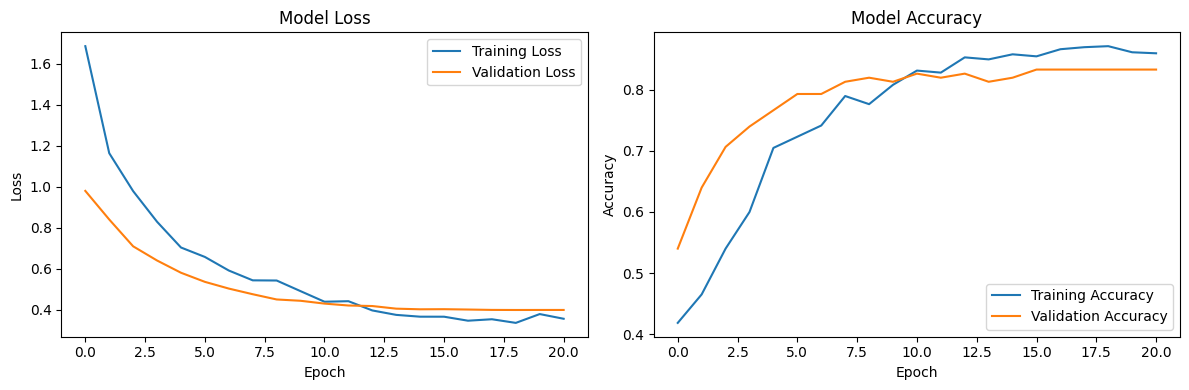

In [26]:
# Function to evaluate model on test set
def evaluate_model(model, test_dataset):
    """Evaluate the trained model on test dataset"""
    results = model.evaluate(test_dataset, verbose=1)
    print(f"Test loss: {results[0]:.4f}")
    print(f"Test accuracy: {results[1]:.4f}")

if __name__ == "__main__":

    # Plot training history
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [27]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [28]:
# Class names mapping
CLASS_NAMES = {
    0: 'airplane',
    1: 'automobile',
    2: 'truck'
}

def load_and_preprocess_sample(image_path, mask_path):
    """Load and preprocess a single sample"""
    # Load and preprocess image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [128, 128])
    image = tf.cast(image, tf.float32) / 255.0

    # Load and preprocess mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=3)  # Assuming mask is 3 channels after prediction
    mask = tf.image.resize(mask, [128, 128])
    mask = tf.cast(mask, tf.float32) / 255.0

    # Combine image and mask
    combined = tf.concat([image, mask], axis=-1)

    return combined, image, mask


def get_test_data(test_dir, mask_dir):
    """Get test data and their true labels"""
    image_paths = []
    mask_paths = []
    true_labels = []

    for class_idx in CLASS_NAMES.keys():
        class_dir = os.path.join(test_dir, str(class_idx))
        mask_class_dir = os.path.join(mask_dir, str(class_idx))

        if not os.path.isdir(class_dir):
            continue

        for img_name in os.listdir(class_dir):
            if img_name.endswith(('.png', '.jpg', '.jpeg')):  # Ensure valid image format
                image_paths.append(os.path.join(class_dir, img_name))
                mask_paths.append(os.path.join(mask_class_dir, img_name))
                true_labels.append(class_idx)

    return image_paths, mask_paths, true_labels


# **Classification Report**


Classification Report:
              precision    recall  f1-score   support

    airplane       0.90      0.92      0.91        62
  automobile       0.85      0.90      0.87        49
       truck       0.83      0.74      0.78        39

    accuracy                           0.87       150
   macro avg       0.86      0.85      0.86       150
weighted avg       0.87      0.87      0.87       150



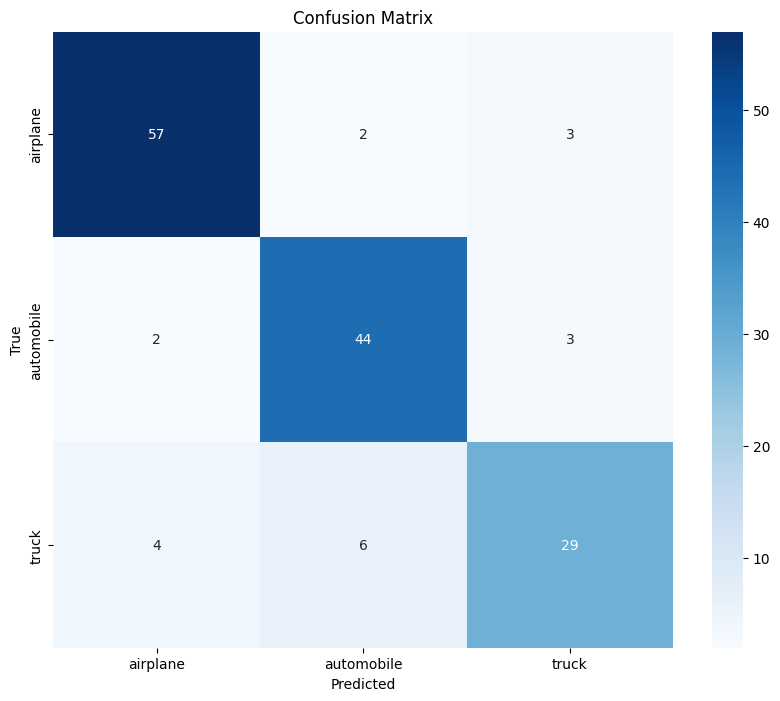

In [48]:

# Define CLASS_NAMES as per your use case
CLASS_NAMES = {
    0: 'airplane',
    1: 'automobile',
    2: 'truck'
}

# Define your custom function for the Lambda layer
def get_item(x):
    return x[:, :, :3]  # Assuming you're slicing the first 3 channels

def generate_classification_report(model, test_dir="cifar10/test", mask_dir="predicted_masks/test"):
    """Generate and print classification report"""
    # Get test data (this part assumes you have your own implementation for fetching data)
    image_paths, mask_paths, true_labels = get_test_data(test_dir, mask_dir)

    # Make predictions
    predictions = []
    for img_path, mask_path in zip(image_paths, mask_paths):
        combined, _, _ = load_and_preprocess_sample(img_path, mask_path)
        pred = model.predict(tf.expand_dims(combined, 0), verbose=0)
        predictions.append(np.argmax(pred))

    # Generate classification report
    print("\nClassification Report:")
    print(classification_report(true_labels, predictions,
                              target_names=[CLASS_NAMES[i] for i in range(len(CLASS_NAMES))]))

    # Generate confusion matrix
    cm = confusion_matrix(true_labels, predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[CLASS_NAMES[i] for i in range(len(CLASS_NAMES))],
                yticklabels=[CLASS_NAMES[i] for i in range(len(CLASS_NAMES))])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


def main():
    # Use custom_object_scope to register the custom function (Lambda layer) during model loading
    with tf.keras.utils.custom_object_scope({'get_item': get_item}):
        # Load the trained model and ensure the custom Lambda function is passed via custom_objects
        model = tf.keras.models.load_model('best_classifier_final.keras')

    # Generate and print classification report
    generate_classification_report(model)


if __name__ == "__main__":
    main()


# **Prediction**

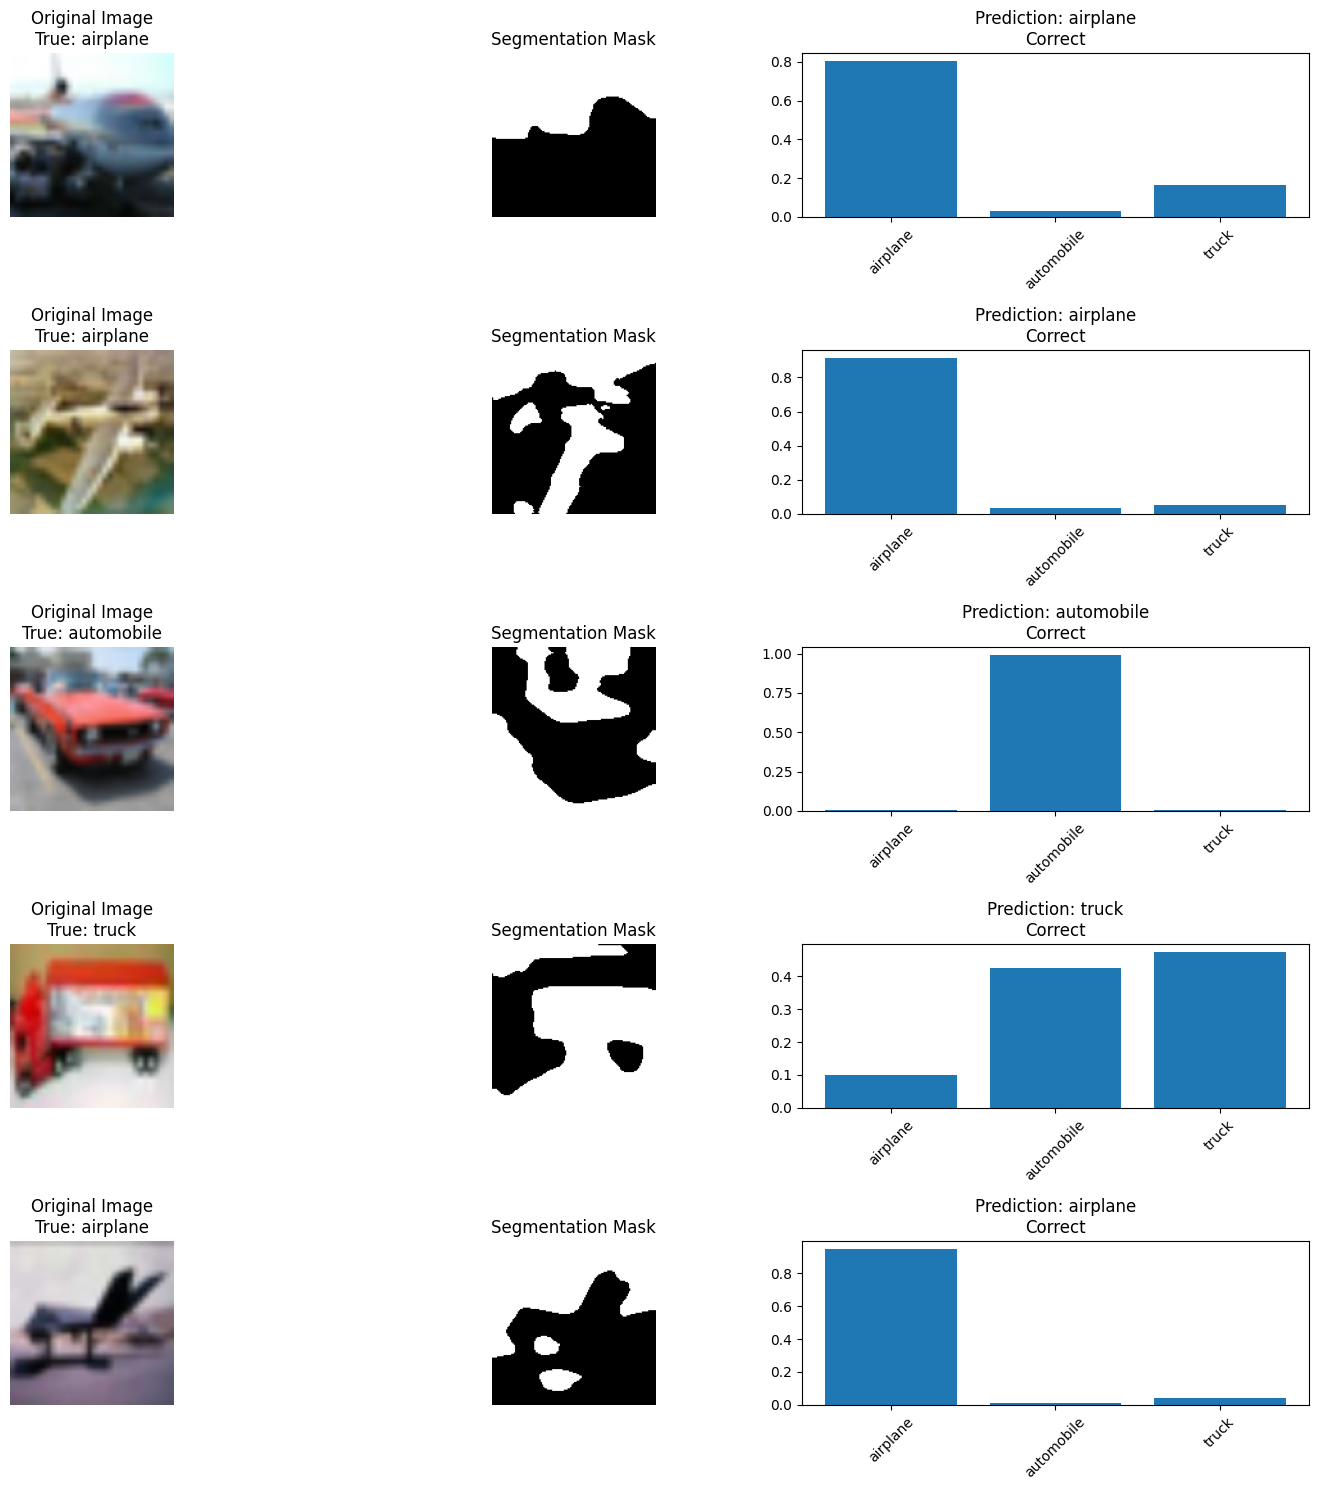

In [50]:
import random

def visualize_predictions(model, test_dir="cifar10/test", mask_dir="predicted_masks/test", num_samples=5):
    """Visualize predictions on random samples"""
    # Get test data
    image_paths, mask_paths, true_labels = get_test_data(test_dir, mask_dir)

    # Randomly select samples
    indices = random.sample(range(len(image_paths)), min(num_samples, len(image_paths)))

    # Create subplot grid
    fig = plt.figure(figsize=(15, 3*num_samples))

    for idx, sample_idx in enumerate(indices):
        # Load and preprocess sample
        combined, image, mask = load_and_preprocess_sample(
            image_paths[sample_idx],
            mask_paths[sample_idx]
        )

        # Make prediction
        pred = model.predict(tf.expand_dims(combined, 0), verbose=0)
        pred_class = np.argmax(pred)
        true_class = true_labels[sample_idx]

        # Plot original image
        plt.subplot(num_samples, 3, idx*3 + 1)
        plt.imshow(image)
        plt.title(f'Original Image\nTrue: {CLASS_NAMES[true_class]}')
        plt.axis('off')

        # Plot mask
        plt.subplot(num_samples, 3, idx*3 + 2)
        plt.imshow(mask)
        plt.title('Segmentation Mask')
        plt.axis('off')

        # Plot prediction info
        plt.subplot(num_samples, 3, idx*3 + 3)
        plt.bar(CLASS_NAMES.values(), pred[0])
        plt.title(f'Prediction: {CLASS_NAMES[pred_class]}\n{"Correct" if pred_class == true_class else "Incorrect"}')
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

def main():
    # Load the trained model
    model = tf.keras.models.load_model('best_classifier_final.keras')

    # Visualize predictions on random samples
    visualize_predictions(model, num_samples=5)

if __name__ == "__main__":
    main()


### predict random image from internet

In [ ]:

import tensorflow as tf
import numpy as np
import cv2
from PIL import Image
import requests
from io import BytesIO

# Load the segmentation model
segmentation_model = tf.keras.models.load_model('seg_model.h5')

# Load the classification model
classification_model = tf.keras.models.load_model('best_classifier_final.keras')

IMG_WIDTH = 128
IMG_HEIGHT = 128
IMG_SIZE = 128
NUM_CLASSES = 3 # Assuming 3 classes

def load_and_preprocess_image(image_url, image_size=(IMG_WIDTH, IMG_HEIGHT)):
    try:
        response = requests.get(image_url, stream=True)
        response.raise_for_status()  # Raise an exception for bad status codes

        image = Image.open(BytesIO(response.content))
        image = image.convert("RGB") # Ensure image is RGB
        image = np.array(image)
        image = cv2.resize(image, image_size)
        image = image.astype('float32') / 255.0
        return image
    except requests.exceptions.RequestException as e:
        print(f"Error downloading image: {e}")
        return None
    except Exception as e:
        print(f"Error processing image: {e}")
        return None


def predict_on_image(image_url):
    image = load_and_preprocess_image(image_url)

    if image is None:
        return None, None

    # 1. Segmentation prediction
    mask_pred = segmentation_model.predict(np.expand_dims(image, 0), verbose = 0)[0]
    mask_img = (np.argmax(mask_pred, axis=-1) * 255).astype(np.uint8)
    mask_img = cv2.resize(mask_img, (IMG_SIZE, IMG_SIZE)) #resize mask to match input size of classification model
    mask_img = np.expand_dims(mask_img, axis=-1)
    mask_img = np.repeat(mask_img, 3, axis=-1) # Create RGB mask (replicate the mask channel 3 times for 3-channel RGB input)
    mask_img = mask_img.astype('float32')/255.0

    # 2. Combine original image and mask
    combined_image = np.concatenate((image,mask_img),axis = -1)
    combined_image = np.expand_dims(combined_image, axis=0)

    # 3. Classification prediction
    class_probabilities = classification_model.predict(combined_image, verbose = 0)[0]
    predicted_class = np.argmax(class_probabilities)

    return predicted_class, class_probabilities


# Example usage
image_url = "https://www.seekpng.com/png/small/260-2608499_rent-sedan-cars-in-jaipur-white-toyota-etios.png" # Replace with your image URL
predicted_class, probabilities = predict_on_image(image_url)

if predicted_class is not None:
    class_names = ["airplane", "automobile", "truck"] # Replace with your actual class names
    print(f"Predicted class: {class_names[predicted_class]}")
    print(f"Class probabilities: {probabilities}")